<div style="background:linear-gradient(135deg,#3b0764 0%,#7e22ce 55%,#a855f7 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#e9d5ff;font-weight:700;text-transform:uppercase">Chapter 90 · Correlation &amp; Association</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Correlation Coefficients 📈</div>
  <div style="font-size:15px;color:#faf5ff;max-width:740px;line-height:1.6">Correlation standardizes covariance into a -1 to 1 ruler for the strength of a relationship. We build Pearson's r and r-squared, Spearman's rank correlation for curves and outliers, and partial correlation to control for a third variable, then read a real fitness correlation heatmap.</div>
  <div style="margin-top:16px;font-size:13px;color:#e9d5ff">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
PUR="#9333ea"; DEEP="#7e22ce"; LIGHT="#c084fc"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(90)

<div style="background:#faf5ff;border-left:5px solid #9333ea;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7e22ce;letter-spacing:1px">DEMO 1 · PEARSON'S r AND r-SQUARED</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Standardized covariance, on a -1 to 1 ruler</div>
<div style="color:#4a5578;margin-top:6px">Pearson's r is covariance divided by the two standard deviations: a unitless number in [-1, 1]. Its sign is direction, its magnitude is strength. Squaring it (r^2) gives the SHARE of one variable's variance that is linearly explained by the other.</div>
</div>

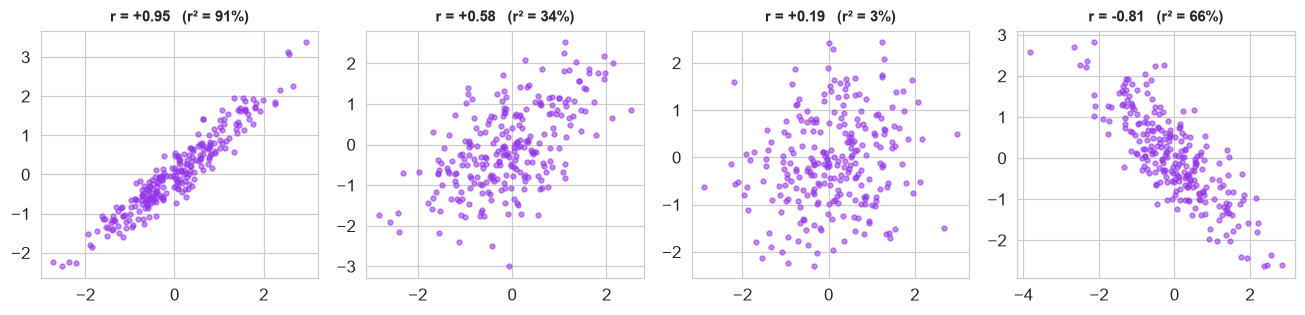

Pearson r = 0.699 (p=5.7e-38), r^2 = 0.489 -> ~49% of y’s variance is linearly explained by x


In [2]:
def make(rho,n=250): x=rng.normal(0,1,n); return x, rho*x+np.sqrt(max(1-rho**2,0))*rng.normal(0,1,n)
fig,ax=plt.subplots(1,4,figsize=(12,3))
for a,rho in zip(ax,[0.95,0.6,0.2,-0.8]):
    x,y=make(rho); r,_=stats.pearsonr(x,y)
    a.scatter(x,y,s=10,color=PUR,alpha=0.55)
    a.set_title(f"r = {r:+.2f}   (r\u00b2 = {r**2:.0%})", fontsize=10)
plt.tight_layout(); plt.show()
x,y=make(0.7); r,p=stats.pearsonr(x,y)
print(f"Pearson r = {r:.3f} (p={p:.1e}), r^2 = {r**2:.3f} -> ~{r**2:.0%} of y\u2019s variance is linearly explained by x")

Read r as direction + strength on a fixed ruler: &#177;1 is a perfect line, 0 is none. The handy companion is <strong>r&#178;</strong>: an r of 0.7 means about 49% of the variation is shared, a useful reframing of "how much does knowing x tell me about y?"

<div style="background:#faf5ff;border-left:5px solid #9333ea;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7e22ce;letter-spacing:1px">DEMO 2 · WHEN PEARSON MISLEADS: SPEARMAN</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Rank correlation for monotonic or messy data</div>
<div style="color:#4a5578;margin-top:6px">Pearson only measures LINEAR association. For a relationship that is monotonic but curved, or data with an outlier, Pearson understates the link. Spearman's rho is Pearson's r computed on the RANKS, so it captures any monotonic relationship and shrugs off outliers.</div>
</div>

y = x^3 :  Pearson r = 0.90   Spearman rho = 0.93  (Spearman sees the perfect monotonic link)
with one outlier: Pearson +0.21 (wrecked) vs Spearman +0.89 (robust)


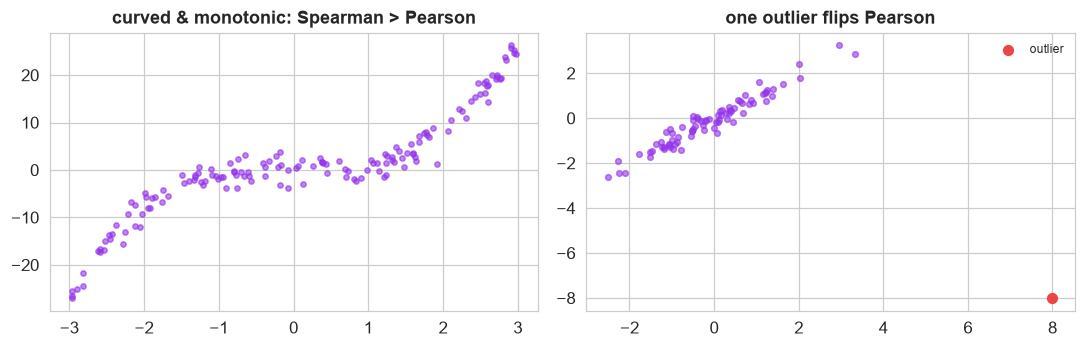

In [3]:
# (a) a monotonic but curved relationship: y = x**3
x=np.sort(rng.uniform(-3,3,150)); y=x**3 + rng.normal(0,2,150)
print(f"y = x^3 :  Pearson r = {stats.pearsonr(x,y)[0]:.2f}   Spearman rho = {stats.spearmanr(x,y)[0]:.2f}  (Spearman sees the perfect monotonic link)")
# (b) one outlier wrecks Pearson but not Spearman
a=rng.normal(0,1,80); b=a+rng.normal(0,0.3,80); a2,b2=a.copy(),b.copy(); a2[0],b2[0]=8,-8
print(f"with one outlier: Pearson {stats.pearsonr(a2,b2)[0]:+.2f} (wrecked) vs Spearman {stats.spearmanr(a2,b2)[0]:+.2f} (robust)")
fig,ax=plt.subplots(1,2,figsize=(10,3.3))
ax[0].scatter(x,y,s=12,color=PUR,alpha=0.6); ax[0].set_title("curved & monotonic: Spearman > Pearson")
ax[1].scatter(a2,b2,s=14,color=PUR,alpha=0.6); ax[1].scatter([8],[-8],color=RED,s=40,label="outlier"); ax[1].set_title("one outlier flips Pearson"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Use <strong>Spearman</strong> when the relationship is monotonic but not straight, when there are outliers, or when the data are ordinal (ranks/ratings). It answers "do they move together in order?" rather than "do they fall on a line?"

<div style="background:#faf5ff;border-left:5px solid #9333ea;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7e22ce;letter-spacing:1px">DEMO 3 · PARTIAL CORRELATION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The correlation between x and y after removing a third variable z</div>
<div style="color:#4a5578;margin-top:6px">Sometimes x and y correlate only because both depend on a third variable z. PARTIAL correlation controls for z: regress x on z and y on z, then correlate the RESIDUALS, the part of each not explained by z. (This is the engine of Chapter 91.)</div>
</div>

In [4]:
z=rng.normal(0,1,300)                 # the common driver
x=z+rng.normal(0,0.5,300); y=z+rng.normal(0,0.5,300)   # x and y share only z
print(f"raw corr(x, y) = {stats.pearsonr(x,y)[0]:.2f}  (looks related)")
def resid(v,w): return sm.OLS(v, sm.add_constant(w)).fit().resid
pc = stats.pearsonr(resid(x,z), resid(y,z))[0]
print(f"partial corr(x, y | z) = {pc:.2f}  (collapses: the link was entirely through z)")

raw corr(x, y) = 0.80  (looks related)
partial corr(x, y | z) = -0.04  (collapses: the link was entirely through z)


Partial correlation strips out the shared influence of z. When it collapses toward 0, the original correlation was driven by the third variable, the statistical fingerprint of confounding that the next chapter builds on.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · A FITNESS CORRELATION MATRIX</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Read strength and direction from a heatmap</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A gym has 200 members with seven numeric health measures (`ch90_fitness.xlsx`). We explore first, then build a correlation heatmap to read every pairwise relationship at a glance, and check one curved pair with Spearman.

In [5]:
try:    d = pd.read_excel("../../data/ch90_fitness.xlsx", sheet_name="Members")
except FileNotFoundError: d = pd.read_excel(BASE+"ch90_fitness.xlsx", sheet_name="Members")
cols=["age","height_cm","weight_kg","body_fat_pct","weekly_exercise_hrs","resting_hr","vo2max"]
# EXPLORE FIRST: shape, missing, and the spread of each measure
print("shape:", d.shape, "| missing:", d.isna().sum().sum())
print(d[cols].describe().round(1).T[["mean","std","min","max"]])

shape: (200, 8) | missing: 0


                      mean   std    min    max
age                   41.8  12.7   20.0   64.5
height_cm            170.7   9.2  145.5  193.9
weight_kg             72.5   8.9   48.9   97.8
body_fat_pct          14.2   5.6    5.0   28.1
weekly_exercise_hrs    3.6   2.4    0.1   12.0
resting_hr            72.9   7.3   47.0   90.0
vo2max                34.1   7.2   16.5   54.0


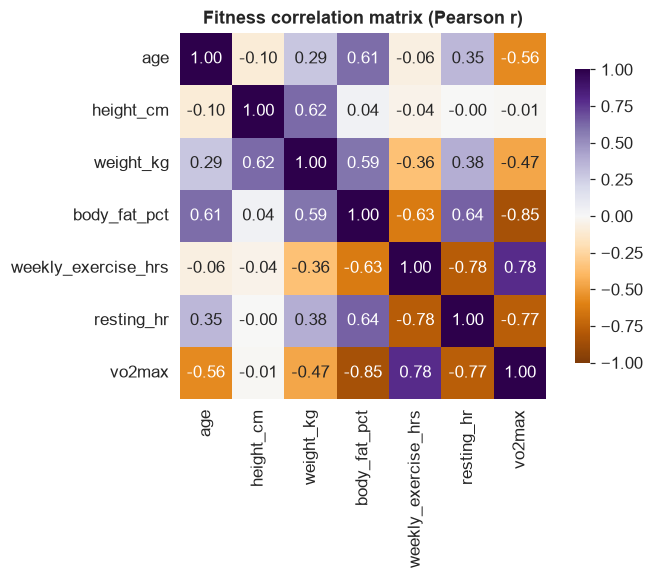

strongest links with vo2max:
body_fat_pct          -0.85
resting_hr            -0.77
age                   -0.56
weight_kg             -0.47
height_cm             -0.01
weekly_exercise_hrs    0.78
Name: vo2max, dtype: float64


In [6]:
corr = d[cols].corr()
fig,ax=plt.subplots(figsize=(7,5.4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="PuOr", center=0, vmin=-1, vmax=1, square=True, ax=ax, cbar_kws=dict(shrink=0.8))
ax.set_title("Fitness correlation matrix (Pearson r)"); plt.tight_layout(); plt.show()
print("strongest links with vo2max:")
print(corr["vo2max"].drop("vo2max").sort_values().round(2))

exercise vs vo2max: Pearson r = 0.78, Spearman rho = 0.81


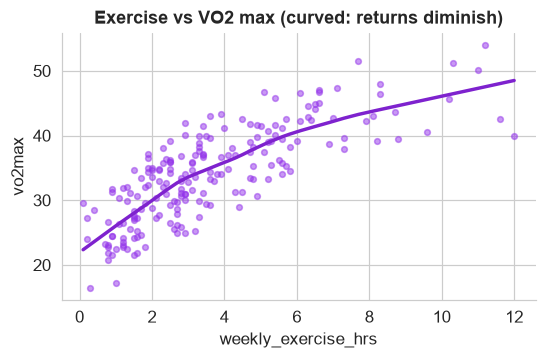

In [7]:
# the exercise -> vo2max link is monotonic but curved (diminishing returns): Spearman beats Pearson
pe=stats.pearsonr(d.weekly_exercise_hrs, d.vo2max)[0]; sp=stats.spearmanr(d.weekly_exercise_hrs, d.vo2max)[0]
print(f"exercise vs vo2max: Pearson r = {pe:.2f}, Spearman rho = {sp:.2f}")
sns.lmplot(data=d, x="weekly_exercise_hrs", y="vo2max", lowess=True, height=3.4, aspect=1.5, scatter_kws=dict(s=14,color=PUR,alpha=0.5), line_kws=dict(color=DEEP))
plt.title("Exercise vs VO2 max (curved: returns diminish)"); plt.tight_layout(); plt.show()

The heatmap reads at a glance: VO2 max is strongly <em>negatively</em> tied to body fat (r &#8776; &#8722;0.85) and resting heart rate (&#8722;0.77), and strongly <em>positively</em> to exercise (&#8776; +0.78). Because the exercise-to-fitness link has diminishing returns (a curve, not a line), <strong>Spearman (&#8776; 0.81) edges out Pearson (&#8776; 0.78)</strong>, the rank measure rewards the monotonic trend the straight-line measure slightly misses. A heatmap plus a sanity-check on shape is the standard first read of any numeric dataset.

<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Correlation coefficients</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Pearson&#39;s r is standardized covariance in [-1, 1]: sign = direction, magnitude = strength, r&#178; = shared variance. Spearman&#39;s rho is r on the ranks, robust to curves and outliers and right for ordinal data. Partial correlation removes a third variable&#39;s influence by correlating residuals. On real fitness data, a heatmap shows body fat and resting HR drag VO2 max down while exercise lifts it. Next: why even a strong correlation does NOT prove causation.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>